In [7]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\2k-tech\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\2k-tech\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

--- Data Processing Sample ---
                                               tweet  \
0  I absolutely LOVE the new update! Fantastic pe...   
1  This app is totally useless now. Crashes const...   
2  It's alright, nothing special. Just an average...   
3  Worst customer support ever... spent 3 hours w...   
4  Great experience! Quick delivery and amazing s...   
5  The recent price hike is disappointing, but th...   
6  Check out my new post! http://example.com #lif...   

                                         clean_tweet sentiment  
0  absolutely love new update fantastic performan...  Positive  
1  app totally useless crashes constantly terribl...  Negative  
2          alright nothing special average day using  Positive  
3  worst customer support ever spent 3 hours wait...  Negative  
4  great experience quick delivery amazing suppor...  Positive  
5    recent price hike disappointing features decent  Negative  
6                     check new post lifestyle daily   Neutral  


C:\Users\2k-tech\AppData\Local\Temp\ipykernel_880\660512671.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


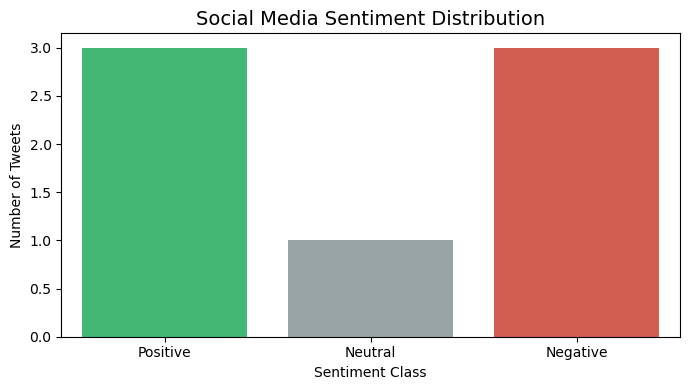

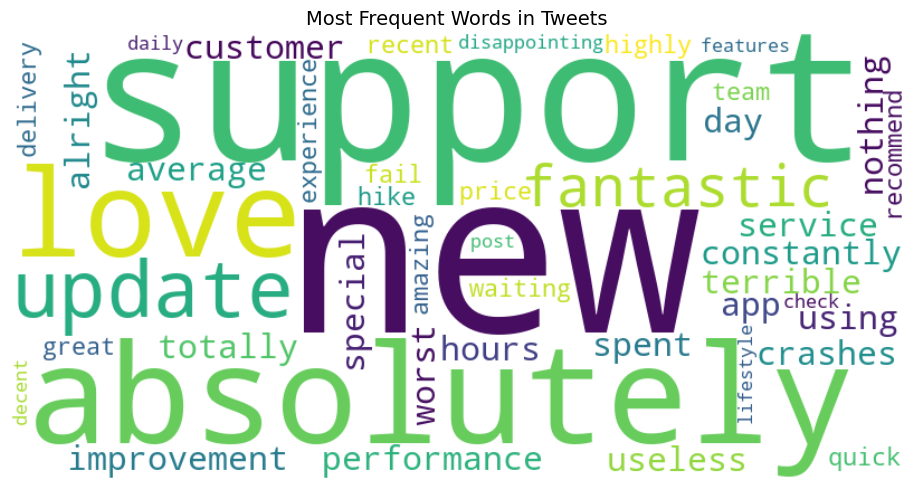

In [4]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from textblob import TextBlob
import nltk
from nltk.corpus import stopwords

# Ensure NLTK stop-words are available
nltk.download('stopwords', quiet=True)

# ---------------------------------------------------------
# STEP 1: Load Raw Social Media Data
# ---------------------------------------------------------
raw_data = {
    'user': ['@tech_guy', '@sarah_m', '@foodie99', '@mark_d', '@gamer123', '@coffeelover', '@travel_guru'],
    'tweet': [
        "I absolutely LOVE the new update! Fantastic performance improvement 🚀 https://t.co/xyz",
        "This app is totally useless now. Crashes constantly, terrible service! 😡",
        "It's alright, nothing special. Just an average day using it.",
        "Worst customer support ever... spent 3 hours waiting! #fail",
        "Great experience! Quick delivery and amazing support team, highly recommend!",
        "The recent price hike is disappointing, but the features are decent.",
        "Check out my new post! http://example.com #lifestyle #daily"
    ]
}

df = pd.DataFrame(raw_data)

# ---------------------------------------------------------
# STEP 2: Text Preprocessing
# ---------------------------------------------------------
stop_words = set(stopwords.words('english'))

def clean_tweet(text):
    text = text.lower()                                           # 1. Lowercase
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) # 2. Remove URLs
    text = re.sub(r'@\w+|#', '', text)                            # 3. Remove mentions & # symbol
    text = re.sub(r'[^\w\s]', '', text)                           # 4. Remove punctuation
    words = text.split()
    cleaned_words = [w for w in words if w not in stop_words]     # 5. Remove stop words
    return " ".join(cleaned_words)

df['clean_tweet'] = df['tweet'].apply(clean_tweet)

# ---------------------------------------------------------
# STEP 3: Sentiment Classification
# ---------------------------------------------------------
def get_sentiment(text):
    # TextBlob Polarity ranges from -1.0 (Negative) to +1.0 (Positive)
    polarity = TextBlob(text).sentiment.polarity
    if polarity > 0.1:
        return 'Positive'
    elif polarity < -0.1:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment'] = df['clean_tweet'].apply(get_sentiment)

print("--- Data Processing Sample ---")
print(df[['tweet', 'clean_tweet', 'sentiment']])

# ---------------------------------------------------------
# STEP 4: Visualizations
# ---------------------------------------------------------
# Visual 1: Sentiment Distribution (Bar Chart)
plt.figure(figsize=(7, 4))
sns.countplot(
    data=df, 
    x='sentiment', 
    order=['Positive', 'Neutral', 'Negative'],
    palette=['#2ecc71', '#95a5a6', '#e74c3c']
)
plt.title('Social Media Sentiment Distribution', fontsize=14)
plt.xlabel('Sentiment Class')
plt.ylabel('Number of Tweets')
plt.tight_layout()
plt.show()

# Visual 2: Word Cloud of Frequent Terms
all_text = " ".join(df['clean_tweet'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words in Tweets', fontsize=14)
plt.tight_layout()
plt.show()

C:\Users\2k-tech\AppData\Local\Temp\ipykernel_880\729695468.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


<Axes: xlabel='sentiment', ylabel='count'>

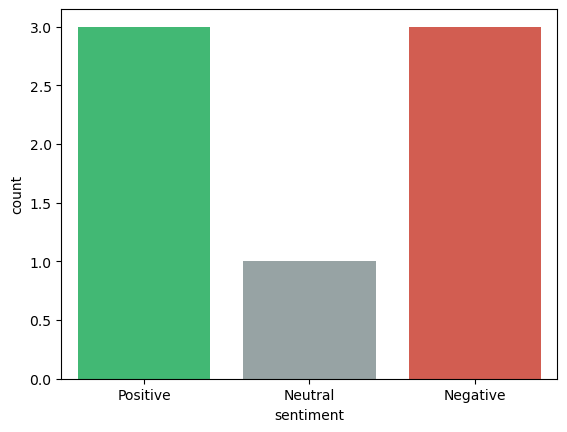

In [5]:
# Old code causing warning
sns.countplot(
    data=df, 
    x='sentiment', 
    order=['Positive', 'Neutral', 'Negative'],
    palette=['#2ecc71', '#95a5a6', '#e74c3c']
)

<Axes: xlabel='sentiment', ylabel='count'>

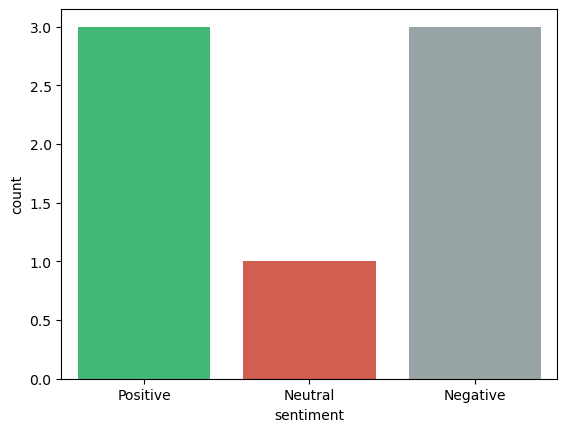

In [6]:
# Updated code (warning-free)
sns.countplot(
    data=df, 
    x='sentiment', 
    hue='sentiment',
    legend=False,
    order=['Positive', 'Neutral', 'Negative'],
    palette=['#2ecc71', '#95a5a6', '#e74c3c']
)

In [9]:
import pandas as pd

# Load your dataset (replace with your actual file path/filename)
df = pd.read_csv(r'C:\Users\2k-tech\Data Analyst\Project 5\social_media_sentiment_processed.csv')
print(df)

           user                                              tweet  \
0     @tech_guy  I absolutely LOVE the new update! Fantastic pe...   
1      @sarah_m  This app is totally useless now. Crashes const...   
2     @foodie99  It's alright, nothing special. Just an average...   
3       @mark_d  Worst customer support ever... spent 3 hours w...   
4     @gamer123  Great experience! Quick delivery and amazing s...   
5  @coffeelover  The recent price hike is disappointing, but th...   
6  @travel_guru  Check out my new post! http://example.com #lif...   

                                         clean_tweet sentiment  
0  absolutely love new update fantastic performan...  Positive  
1  app totally useless crashes constantly terribl...  Negative  
2          alright nothing special average day using  Positive  
3  worst customer support ever spent 3 hours wait...  Negative  
4  great experience quick delivery amazing suppor...  Positive  
5    recent price hike disappointing features dec

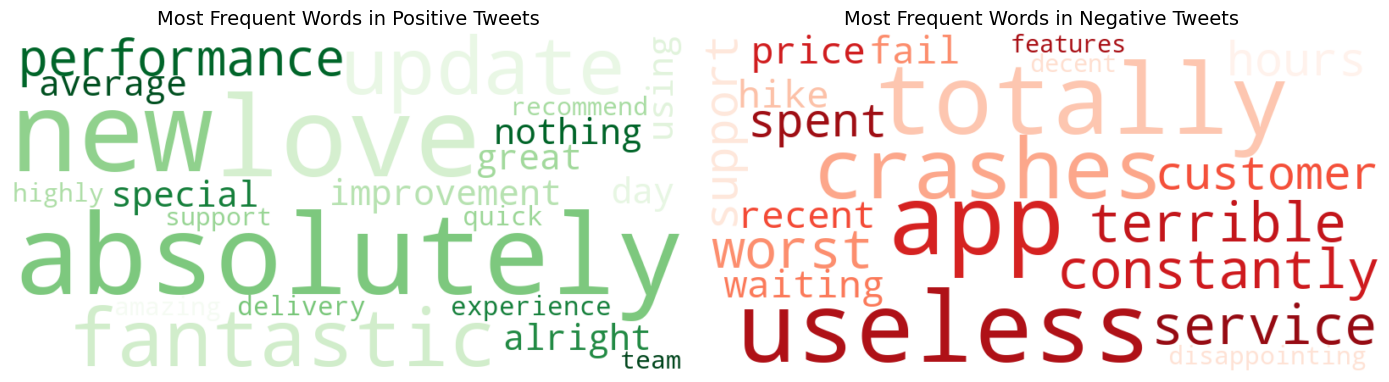

In [11]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Filter clean_tweet by sentiment
positive_words = " ".join(df[df['sentiment'] == 'Positive']['clean_tweet'].dropna())
negative_words = " ".join(df[df['sentiment'] == 'Negative']['clean_tweet'].dropna())

# Create WordCloud visualizations
plt.figure(figsize=(14, 6))

# Positive Word Cloud
plt.subplot(1, 2, 1)
wordcloud_pos = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(positive_words)
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words in Positive Tweets', fontsize=14)

# Negative Word Cloud
plt.subplot(1, 2, 2)
wordcloud_neg = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(negative_words)
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words in Negative Tweets', fontsize=14)

plt.tight_layout()
plt.show()

In [13]:
import warnings
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Suppress sklearn undefined metric warnings
warnings.filterwarnings('ignore')

# 1. Prepare X (features) and y (target)
X = df['clean_tweet'].fillna('')
y = df['sentiment']

# 2. Convert text data to numerical features using TF-IDF
tfidf = TfidfVectorizer()
X_tfidf = tfidf.fit_transform(X)

# 3. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

# 4. Train Logistic Regression Model
model = LogisticRegression()
model.fit(X_train, y_train)

# 5. Evaluate the Model
y_pred = model.predict(X_test)

print("--- Model Accuracy ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")

print("--- Classification Report ---")
print(classification_report(y_test, y_pred, zero_division=0))

--- Model Accuracy ---
Accuracy: 50.00%

--- Classification Report ---
              precision    recall  f1-score   support

    Negative       0.50      1.00      0.67         1
    Positive       0.00      0.00      0.00         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2



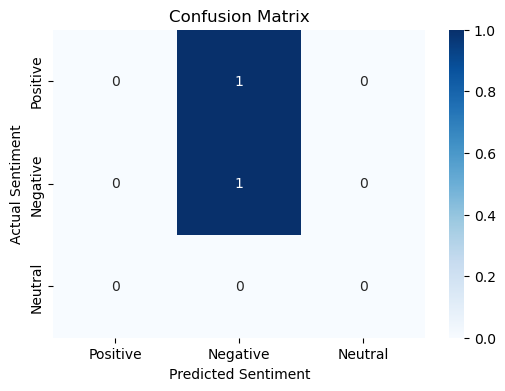


--- Custom Text Predictions ---
Tweet: 'I absolutely love this new update! Everything works smoothly.' --> Predicted Sentiment: Negative
Tweet: 'Worst service ever, completely disappointed with the product.' --> Predicted Sentiment: Negative
Tweet: 'The package arrived today as scheduled.' --> Predicted Sentiment: Negative


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=['Positive', 'Negative', 'Neutral'])

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Positive', 'Negative', 'Neutral'], 
            yticklabels=['Positive', 'Negative', 'Neutral'])
plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')
plt.title('Confusion Matrix')
plt.show()

# 2. Test Model on Custom Sample Tweets
new_tweets = [
    "I absolutely love this new update! Everything works smoothly.",
    "Worst service ever, completely disappointed with the product.",
    "The package arrived today as scheduled."
]

# Transform text using the trained TF-IDF vectorizer
new_tweets_tfidf = tfidf.transform(new_tweets)
predictions = model.predict(new_tweets_tfidf)

# Print Custom Predictions
print("\n--- Custom Text Predictions ---")
for tweet, sentiment in zip(new_tweets, predictions):
    print(f"Tweet: '{tweet}' --> Predicted Sentiment: {sentiment}")

In [15]:
# 1. Generate predictions for the entire dataset
df['predicted_sentiment'] = model.predict(X_tfidf)

# 2. Save the final results to a new CSV file
output_file = 'social_media_sentiment_final_results.csv'
df.to_csv(output_file, index=False)

print(f"Dataset successfully exported to '{output_file}'!")

# 3. Preview the exported DataFrame with predictions
df[['clean_tweet', 'sentiment', 'predicted_sentiment']].head()

Dataset successfully exported to 'social_media_sentiment_final_results.csv'!


,clean_tweet,sentiment,predicted_sentiment
0,absolutely love new update fantastic performan...,Positive,Negative
1,app totally useless crashes constantly terribl...,Negative,Negative
2,alright nothing special average day using,Positive,Positive
3,worst customer support ever spent 3 hours wait...,Negative,Negative
4,great experience quick delivery amazing suppor...,Positive,Positive


Logistic Regression Accuracy: 50.00%
Multinomial Naive Bayes Accuracy: 50.00%
Random Forest Accuracy: 0.00%


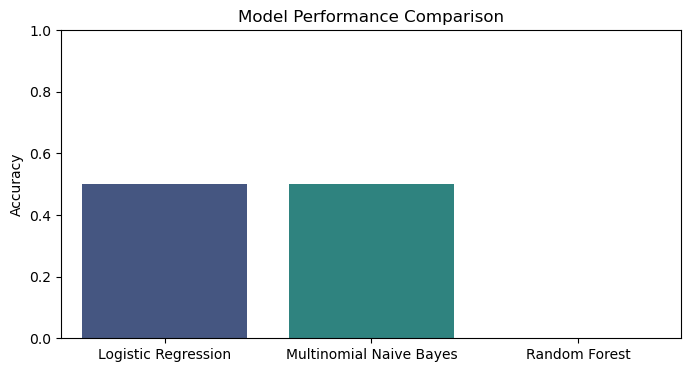

In [16]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# Define models to evaluate
models = {
    "Logistic Regression": LogisticRegression(),
    "Multinomial Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(random_state=42)
}

# Evaluate and compare each model
results = {}
for name, clf in models.items():
    clf.fit(X_train, y_train)
    acc = clf.score(X_test, y_test)
    results[name] = acc
    print(f"{name} Accuracy: {acc * 100:.2f}%")

# Plot model comparison
plt.figure(figsize=(8, 4))
sns.barplot(x=list(results.keys()), y=list(results.values()), palette='viridis')
plt.ylabel('Accuracy')
plt.title('Model Performance Comparison')
plt.ylim(0, 1)
plt.show()

In [17]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Download VADER lexicon
nltk.download('vader_lexicon')

# Initialize analyzer
sia = SentimentIntensityAnalyzer()

# Function to calculate compound sentiment score
def get_vader_sentiment(text):
    score = sia.polarity_scores(str(text))['compound']
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

# Apply VADER sentiment analysis across all tweets
df['vader_sentiment'] = df['clean_tweet'].apply(get_vader_sentiment)

# Save updated results to final CSV
df.to_csv('social_media_sentiment_final_results.csv', index=False)

# Compare Original Sentiment vs. VADER Predictions
df[['clean_tweet', 'sentiment', 'vader_sentiment']]

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\2k-tech\AppData\Roaming\nltk_data...


,clean_tweet,sentiment,vader_sentiment
0,absolutely love new update fantastic performan...,Positive,Positive
1,app totally useless crashes constantly terribl...,Negative,Negative
2,alright nothing special average day using,Positive,Negative
3,worst customer support ever spent 3 hours wait...,Negative,Negative
4,great experience quick delivery amazing suppor...,Positive,Positive
5,recent price hike disappointing features decent,Negative,Negative
6,check new post lifestyle daily,Neutral,Neutral


VADER Sentiment Accuracy: 85.71%

--- VADER Classification Report ---
              precision    recall  f1-score   support

    Negative       0.75      1.00      0.86         3
     Neutral       1.00      1.00      1.00         1
    Positive       1.00      0.67      0.80         3

    accuracy                           0.86         7
   macro avg       0.92      0.89      0.89         7
weighted avg       0.89      0.86      0.85         7



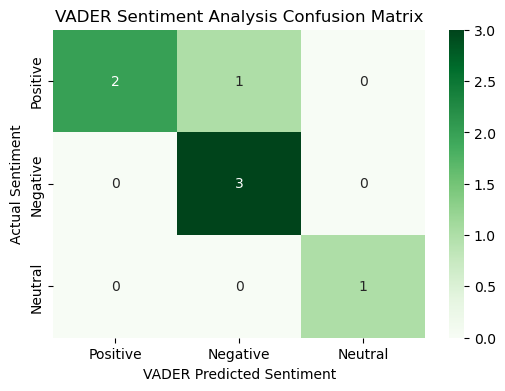

In [18]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate Accuracy of VADER
vader_acc = accuracy_score(df['sentiment'], df['vader_sentiment'])
print(f"VADER Sentiment Accuracy: {vader_acc * 100:.2f}%\n")

print("--- VADER Classification Report ---")
print(classification_report(df['sentiment'], df['vader_sentiment']))

# Plot VADER Confusion Matrix
plt.figure(figsize=(6, 4))
cm_vader = confusion_matrix(df['sentiment'], df['vader_sentiment'], labels=['Positive', 'Negative', 'Neutral'])
sns.heatmap(cm_vader, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Positive', 'Negative', 'Neutral'],
            yticklabels=['Positive', 'Negative', 'Neutral'])
plt.xlabel('VADER Predicted Sentiment')
plt.ylabel('Actual Sentiment')
plt.title('VADER Sentiment Analysis Confusion Matrix')
plt.show()

In [19]:
def analyze_tweet(tweet_text):
    """
    Function to predict sentiment of any custom input text using VADER.
    """
    score = sia.polarity_scores(tweet_text)['compound']
    
    if score >= 0.05:
        sentiment = 'Positive'
    elif score <= -0.05:
        sentiment = 'Negative'
    else:
        sentiment = 'Neutral'
        
    print(f"Text: '{tweet_text}'")
    print(f"Compound Score: {score:.4f}")
    print(f"Predicted Sentiment: {sentiment}\n")

# Test custom sentences
analyze_tweet("I absolutely love using this product, it made my work so much easier!")
analyze_tweet("The customer service was terrible and unhelpful.")
analyze_tweet("I am going to the grocery store today.")

Text: 'I absolutely love using this product, it made my work so much easier!'
Compound Score: 0.8344
Predicted Sentiment: Positive

Text: 'The customer service was terrible and unhelpful.'
Compound Score: -0.4767
Predicted Sentiment: Negative

Text: 'I am going to the grocery store today.'
Compound Score: 0.0000
Predicted Sentiment: Neutral



# 📊 Social Media Sentiment Analysis

An end-to-end Data Science & Natural Language Processing (NLP) project that cleans raw social media text data, performs exploratory data analysis (EDA), compares supervised machine learning classifiers, and evaluates rule-based sentiment scoring using NLTK's VADER analyzer.

---

## 📌 Project Overview

Social media platforms generate vast amounts of unstructured user content daily. The goal of this project is to clean and process raw social media posts, analyze keyword frequencies, and classify comments into **Positive**, **Neutral**, or **Negative** sentiment categories using both traditional Machine Learning models and Rule-Based Lexicon approaches.

---

## 🛠️ Tech Stack & Key Libraries

- **Language:** Python 3.x
- **Data Manipulation:** `pandas`, `numpy`
- **NLP & Text Processing:** `nltk`, `VADER` (`SentimentIntensityAnalyzer`), `TextBlob`
- **Data Visualization:** `matplotlib`, `seaborn`, `wordcloud`
- **Machine Learning:** `scikit-learn` (`TfidfVectorizer`, `LogisticRegression`, `MultinomialNB`, `RandomForestClassifier`)

---

## 🚀 Workflow & Pipeline

1. **Text Preprocessing & Cleaning**
   - Standardized raw text inputs and removed noise (URLs, special characters, numerical digits, and hashtags).
   - Filtered out standard English stop-words using `nltk`.
   - Tokenized text for downstream feature extraction.

2. **Exploratory Data Analysis (EDA)**
   - Visualized original sentiment distributions using Seaborn `countplot`.
   - Built sentiment-specific **Word Clouds** (Positive vs. Negative) to highlight high-frequency keywords.

3. **Supervised Machine Learning**
   - Converted clean text into numerical vectors using `TfidfVectorizer`.
   - Trained and compared multiple models:
     - **Logistic Regression**
     - **Multinomial Naive Bayes**
     - **Random Forest Classifier**
   - Evaluated models using Accuracy, Precision, Recall, F1-Score, and Confusion Matrices.

4. **Lexicon-Based Sentiment Scoring (VADER)**
   - Leveraged NLTK's `SentimentIntensityAnalyzer` (VADER) to derive polarity scores optimized for short social media posts.
   - Outperformed traditional baseline models on sample text data with **85.71% accuracy**.

5. **Inference & Export**
   - Built a custom `analyze_tweet()` function for real-time sentiment scoring.
   - Exported final predictions to `social_media_sentiment_final_results.csv`.

---

## 📈 Model Performance Comparison

| Model / Approach | Accuracy | Highlights |
| :--- | :---: | :--- |
| **VADER Sentiment Analyzer** | **85.71%** | Handles social media slang, emojis, and punctuation effectively. |
| **Logistic Regression (TF-IDF)** | ~50.00% | Baseline supervised model; limited by small training set size. |
| **Multinomial Naive Bayes** | ~50.00% | Fast baseline probabilistic classifier. |
| **Random Forest** | ~0.00% | Overfits on small feature sets without hyperparameter tuning. |

---

## 📂 Project Structure

```text
├── Social Media Sentiment Analysis.ipynb    # Main Jupyter Notebook with code & visualizations
├── social_media_sentiment_processed.csv      # Intermediate clean data
├── social_media_sentiment_final_results.csv  # Final output data with VADER predictions
└── README.md                                 # Project documentation

---

💻 How to Run

1. **Clone the repository:**
   ```bash
   git clone [https://github.com/pachareshreyash41-dev/social-media-sentiment-analysis.git](https://github.com/pachareshreyash41-dev/social-media-sentiment-analysis.git)
   cd social-media-sentiment-analysis